# 데이터 불러오기와 첫 전처리

# scaler 차이 확인용 테스트 데이터 만들기

`StandardScaler`, `MinMaxScaler`, `MaxAbsScaler`, `RobustScaler`의 차이비교.

이번에는 차이가 더 잘 보이도록 아래처럼 데이터를 다시 만듭니다.
- 대부분의 정상 데이터는 `50` 근처에 모입니다.
- 낮은 쪽 이상치와 높은 쪽 이상치를 함께 넣습니다.
- 아주 극단적인 음수/양수 이상치도 조금 섞습니다.
- 데이터를 섞어서 실제 데이터처럼 이상치가 중간중간 섞여 보이게 합니다.

핵심 관찰 포인트는 다음입니다.
- `MinMaxScaler`: 최솟값과 최댓값을 기준으로 `0~1`에 강제로 넣습니다.
- `MaxAbsScaler`: 절댓값이 가장 큰 값을 기준으로 `-1~1` 범위에 맞춥니다.
- `StandardScaler`: 평균과 표준편차를 기준으로 바꾸므로 이상치에 영향을 많이 받습니다.
- `RobustScaler`: 중앙값과 IQR을 기준으로 바꾸므로 이상치에 상대적으로 덜 흔들립니다.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

In [2]:
# 재현 가능한 예제를 위해 난수 시드를 고정합니다.
rng = np.random.default_rng(42) #랜덤값을 42개 생성

In [3]:
# 1) 대부분의 정상 데이터: 50 근처에 정규분포를 따르는 난수 생성 (평균 50, 표준편차: 20, 개수 220개)
normal = rng.normal(loc=50, scale=8, size=220)
normal = np.clip(normal, 35, 65)

In [4]:
# 2) 약한 이상치: 정상 범위에서 조금 벗어난 값, 50근처가 아닌 다른 범위로 값 생성
moderate_low = rng.normal(loc=10, scale=2, size=8)
moderate_high = rng.normal(loc=90, scale=3, size=8)

In [5]:
# 3) 강한 이상치: scaler 차이를 눈에 띄게 만들기 위한 극단값
extreme_low = np.array([-120, -95, -80])
extreme_high = np.array([180, 220, 260])

In [8]:
values = np.concatenate([ #임의데이터 생성
    normal, #정상
    moderate_low,
    moderate_high,
    extreme_low,
    extreme_high,
])

In [9]:
groups = (
    ["정상"] * len(normal)
    + ["낮은 쪽 약한 이상치"] * len(moderate_low)
    + ["높은 쪽 약한 이상치"] * len(moderate_high)
    + ["낮은 쪽 강한 이상치"] * len(extreme_low)
    + ["높은 쪽 강한 이상치"] * len(extreme_high)
)
df_scaler_test = pd.DataFrame({
    "원본값": values,
    "구분": groups,
})

In [10]:
# 실제 데이터처럼 이상치가 중간중간 섞여 보이도록 행 순서를 섞습니다. (frac=1: 전체 데이터의 100%)
df_scaler_test = df_scaler_test.sample(frac=1, random_state=42).reset_index(drop=True)

In [11]:
# scikit-learn scaler는 2차원 입력을 기대하므로 DataFrame/2D array 형태로 준비합니다.
X = df_scaler_test[["원본값"]].to_numpy()

In [12]:
print("데이터 shape:", X.shape)
print("정상 데이터 개수:", (df_scaler_test["구분"] == "정상").sum())
print("이상치 데이터 개수:", (df_scaler_test["구분"] != "정상").sum())

데이터 shape: (242, 1)
정상 데이터 개수: 220
이상치 데이터 개수: 22


In [13]:
df_scaler_test.head(10)

,원본값,구분
0,46.573377,정상
1,51.022723,정상
2,36.602536,정상
3,47.327012,정상
4,-95.000000,낮은 쪽 강한 이상치
5,48.692457,정상
6,63.789326,정상
7,48.730921,정상
8,43.175649,정상
9,38.431537,정상


In [14]:
# 구분별 원본값 요약
df_scaler_test.groupby("구분")["원본값"].agg(["count", "min", "median", "max"]).round(2)

,count,min,median,max
구분,,,,
낮은 쪽 강한 이상치,3,-120.00,-95.00,-80.00
낮은 쪽 약한 이상치,8,7.83,10.40,15.03
높은 쪽 강한 이상치,3,180.00,220.00,260.00
높은 쪽 약한 이상치,8,85.61,88.13,93.62
정상,220,35.00,49.59,65.00


## 원본 데이터 시각화하기

scaler를 적용하기 전에 원본 데이터가 어떻게 생겼는지 먼저 봅니다.

아래 그래프에서 `x` 표시는 이상치입니다. 정상 데이터는 50 근처에 몰려 있고, 몇 개의 값이 아래쪽과 위쪽으로 크게 튀어 있는 것을 볼 수 있습니다.


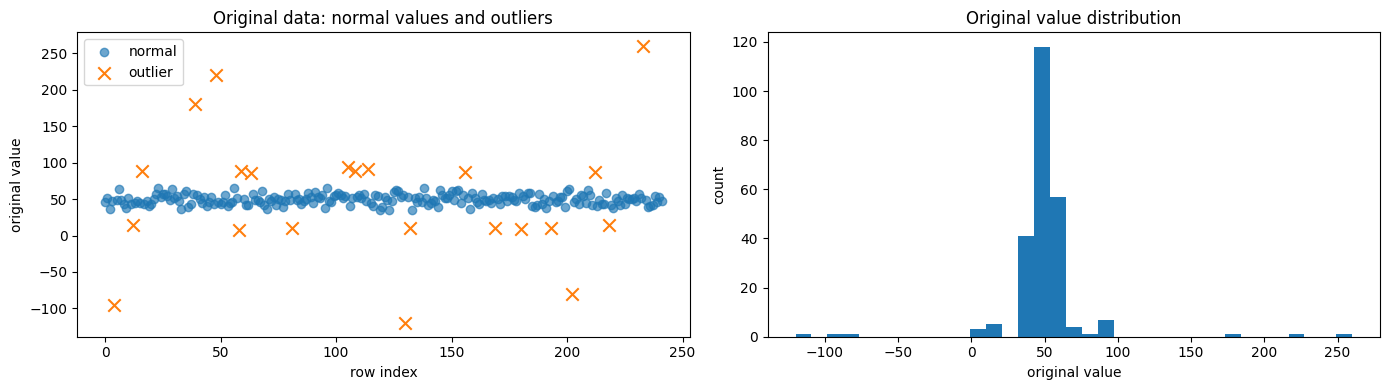

In [15]:
import matplotlib.pyplot as plt

normal_mask = df_scaler_test["구분"].eq("정상")
outlier_mask = ~normal_mask

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 행 순서 기준 산점도: 이상치가 데이터 중간중간 섞여 있음을 보여줍니다.
axes[0].scatter(
    df_scaler_test.index[normal_mask],
    df_scaler_test.loc[normal_mask, "원본값"],
    alpha=0.65,
    label="normal",
)
axes[0].scatter(
    df_scaler_test.index[outlier_mask],
    df_scaler_test.loc[outlier_mask, "원본값"],
    marker="x",
    s=80,
    label="outlier",
)
axes[0].set_title("Original data: normal values and outliers")
axes[0].set_xlabel("row index")
axes[0].set_ylabel("original value")
axes[0].legend()

# 히스토그램: 정상 데이터가 50 근처에 몰려 있음을 보여줍니다.
axes[1].hist(df_scaler_test["원본값"], bins=35)
axes[1].set_title("Original value distribution")
axes[1].set_xlabel("original value")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()


# 4가지 scaler 적용하기

이제 같은 `X`에 4가지 scaler를 모두 적용합니다.

결과를 비교하기 쉽도록 `scaled_df`라는 DataFrame에 원본값, 데이터 구분, scaler별 변환값을 모두 담아 둡니다.

In [16]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler

In [17]:
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "MaxAbsScaler": MaxAbsScaler(),
    "RobustScaler": RobustScaler(),
}

In [18]:
results = {}
scaled_df = df_scaler_test.copy()

In [19]:
for scaler_name, scaler in scalers.items():
    X_scaled = scaler.fit_transform(X)
    results[scaler_name] = X_scaled
    scaled_df[scaler_name] = X_scaled.ravel()

In [20]:
# scaler별 전체 변환 결과 요약
scaled_df[list(scalers.keys())].agg(["min", "mean", "std", "max", "median"]).T.round(3)

,min,mean,std,max,median
StandardScaler,-6.043,0.000,1.002,7.468,-0.013
MinMaxScaler,0.000,0.447,0.074,1.000,0.446
MaxAbsScaler,-0.462,0.192,0.108,1.000,0.191
RobustScaler,-14.642,0.032,2.433,18.167,-0.000


In [21]:
# scaler별 정상 데이터만 봤을 때의 변환 범위
normal_summary = (
    scaled_df.loc[normal_mask, list(scalers.keys())]
    .agg(["min", "median", "max"])
    .T
)
normal_summary["정상데이터_범위폭(max-min)"] = normal_summary["max"] - normal_summary["min"]
display(normal_summary.round(3))

,min,median,max,정상데이터_범위폭(max-min)
StandardScaler,-0.532,-0.013,0.535,1.067
MinMaxScaler,0.408,0.446,0.487,0.079
MaxAbsScaler,0.135,0.191,0.250,0.115
RobustScaler,-1.259,-0.000,1.331,2.590


# 4개 scaler Visualization

아래 그림은 scaler 차이를 일부러 잘 보이게 만든 비교 그래프입니다.

- 위쪽 행: 전체 데이터입니다. 이상치가 scaler별로 어디에 위치하는지 봅니다.
- 아래쪽 행: 정상 데이터만 확대해서 봅니다. 이상치 때문에 정상 데이터가 얼마나 눌리는지 봅니다.

특히 `RobustScaler`는 정상 데이터의 퍼짐이 비교적 잘 살아 있고, 이상치는 멀리 떨어진 값으로 남아 있는 것을 볼 수 있습니다.

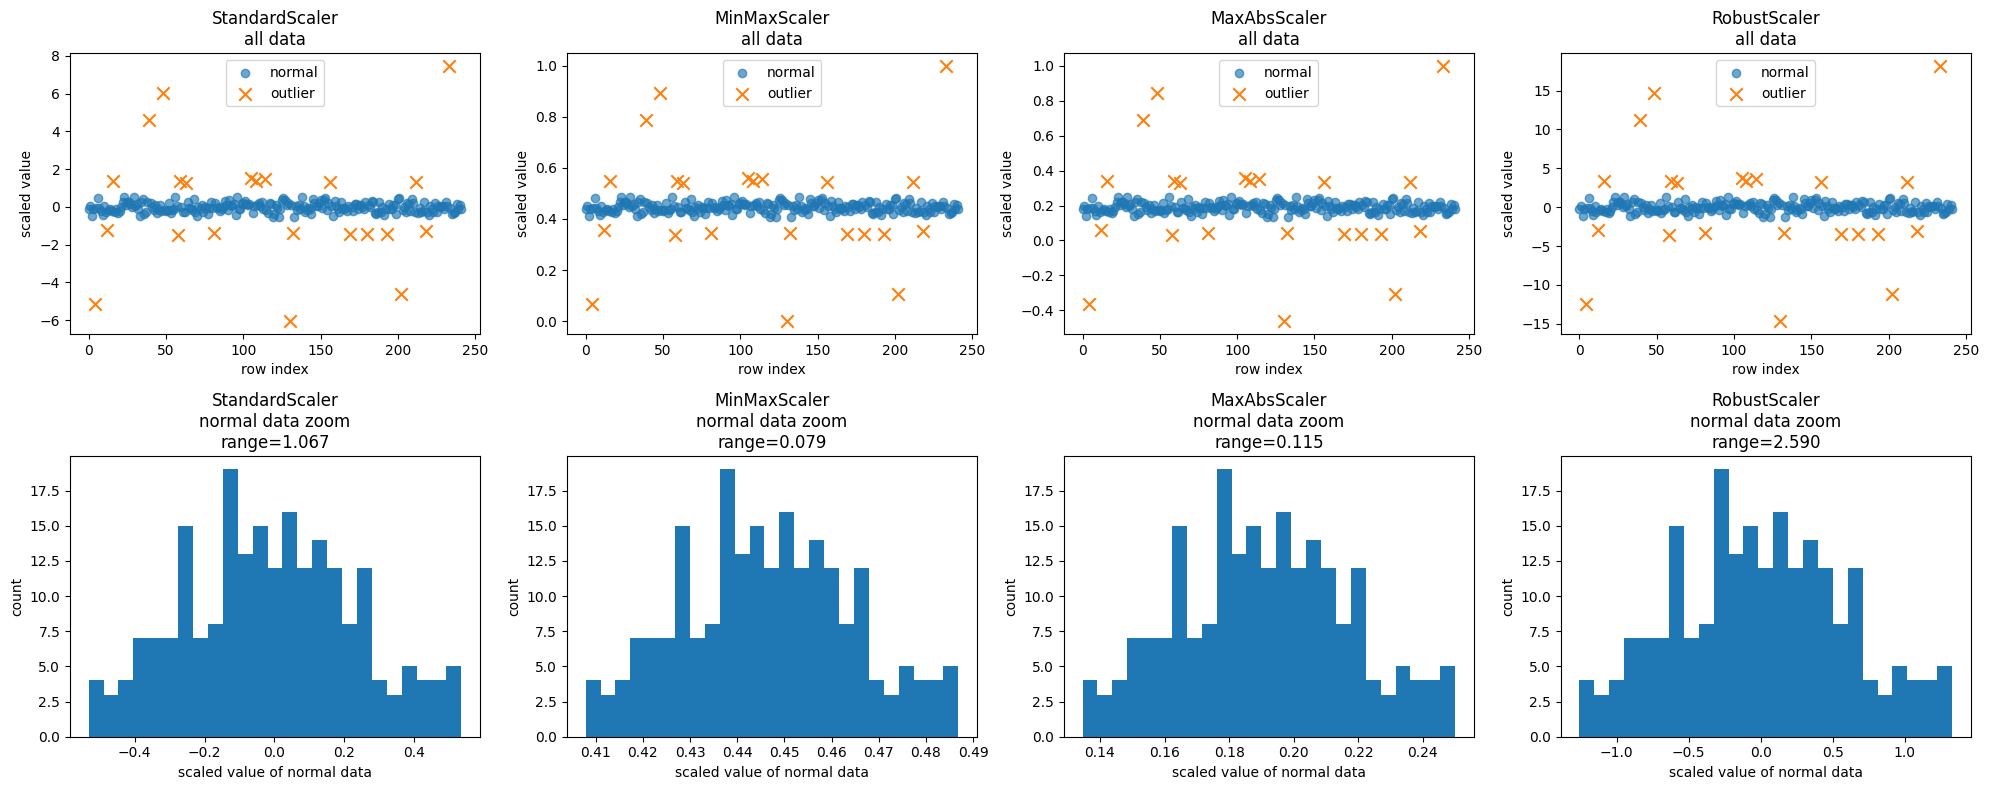

In [22]:
def plot_scaler_comparison_with_outliers(scaled_df, scaler_names):
    normal_mask = scaled_df["구분"].eq("정상")
    outlier_mask = ~normal_mask

    fig, axes = plt.subplots(2, len(scaler_names), figsize=(5 * len(scaler_names), 8))

    for col, scaler_name in enumerate(scaler_names):
        # 1행: 전체 데이터
        ax_all = axes[0, col]
        ax_all.scatter(
            scaled_df.index[normal_mask],
            scaled_df.loc[normal_mask, scaler_name],
            alpha=0.65,
            label="normal",
        )
        ax_all.scatter(
            scaled_df.index[outlier_mask],
            scaled_df.loc[outlier_mask, scaler_name],
            marker="x",
            s=80,
            label="outlier",
        )
        ax_all.set_title(f"{scaler_name}\nall data")
        ax_all.set_xlabel("row index")
        ax_all.set_ylabel("scaled value")
        ax_all.legend()

        # 2행: 정상 데이터만 확대
        ax_normal = axes[1, col]
        ax_normal.hist(
            scaled_df.loc[normal_mask, scaler_name],
            bins=25,
        )
        normal_min = scaled_df.loc[normal_mask, scaler_name].min()
        normal_max = scaled_df.loc[normal_mask, scaler_name].max()
        ax_normal.set_title(
            f"{scaler_name}\nnormal data zoom\nrange={normal_max - normal_min:.3f}"
        )
        ax_normal.set_xlabel("scaled value of normal data")
        ax_normal.set_ylabel("count")

    plt.tight_layout()
    plt.show()


plot_scaler_comparison_with_outliers(scaled_df, list(scalers.keys()))


In [23]:
def plot_scaler_comparison_with_outliers_vertical(scaled_df, scaler_names):
    normal_mask = scaled_df["구분"].eq("정상")
    outlier_mask = ~normal_mask

    n_scalers = len(scaler_names)

    # scaler 하나당 한 줄(row)을 사용
    fig, axes = plt.subplots(
        n_scalers,
        2,
        figsize=(16, 4.5 * n_scalers)
    )

    # scaler가 1개일 때도 동일하게 동작하도록 처리
    if n_scalers == 1:
        axes = np.array([axes])

    for row, scaler_name in enumerate(scaler_names):
        normal_values = scaled_df.loc[normal_mask, scaler_name]
        outlier_values = scaled_df.loc[outlier_mask, scaler_name]

        normal_min = normal_values.min()
        normal_max = normal_values.max()
        normal_range = normal_max - normal_min
        normal_std = normal_values.std()

        # -----------------------------
        # 왼쪽: 전체 데이터
        # -----------------------------
        ax_all = axes[row, 0]

        ax_all.scatter(
            scaled_df.index[normal_mask],
            normal_values,
            alpha=0.65,
            label="normal"
        )

        ax_all.scatter(
            scaled_df.index[outlier_mask],
            outlier_values,
            marker="x",
            s=90,
            label="outlier"
        )

        ax_all.axhline(0, linestyle="--", linewidth=1)

        ax_all.set_title(
            f"{scaler_name} - all data\n"
            f"min={scaled_df[scaler_name].min():.3f}, "
            f"max={scaled_df[scaler_name].max():.3f}"
        )
        ax_all.set_xlabel("row index")
        ax_all.set_ylabel("scaled value")
        ax_all.legend()
        ax_all.grid(alpha=0.3)

        # -----------------------------
        # 오른쪽: 정상 데이터만 확대
        # -----------------------------
        ax_normal = axes[row, 1]

        ax_normal.scatter(
            scaled_df.index[normal_mask],
            normal_values,
            alpha=0.75
        )

        ax_normal.axhline(0, linestyle="--", linewidth=1)

        # 정상 데이터 구간만 보기 좋게 y축 확대
        padding = normal_range * 0.2
        if padding == 0:
            padding = 0.1

        ax_normal.set_ylim(
            normal_min - padding,
            normal_max + padding
        )

        ax_normal.set_title(
            f"{scaler_name} - normal data zoom\n"
            f"normal range={normal_range:.3f}, "
            f"normal std={normal_std:.3f}"
        )
        ax_normal.set_xlabel("row index")
        ax_normal.set_ylabel("scaled value")
        ax_normal.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

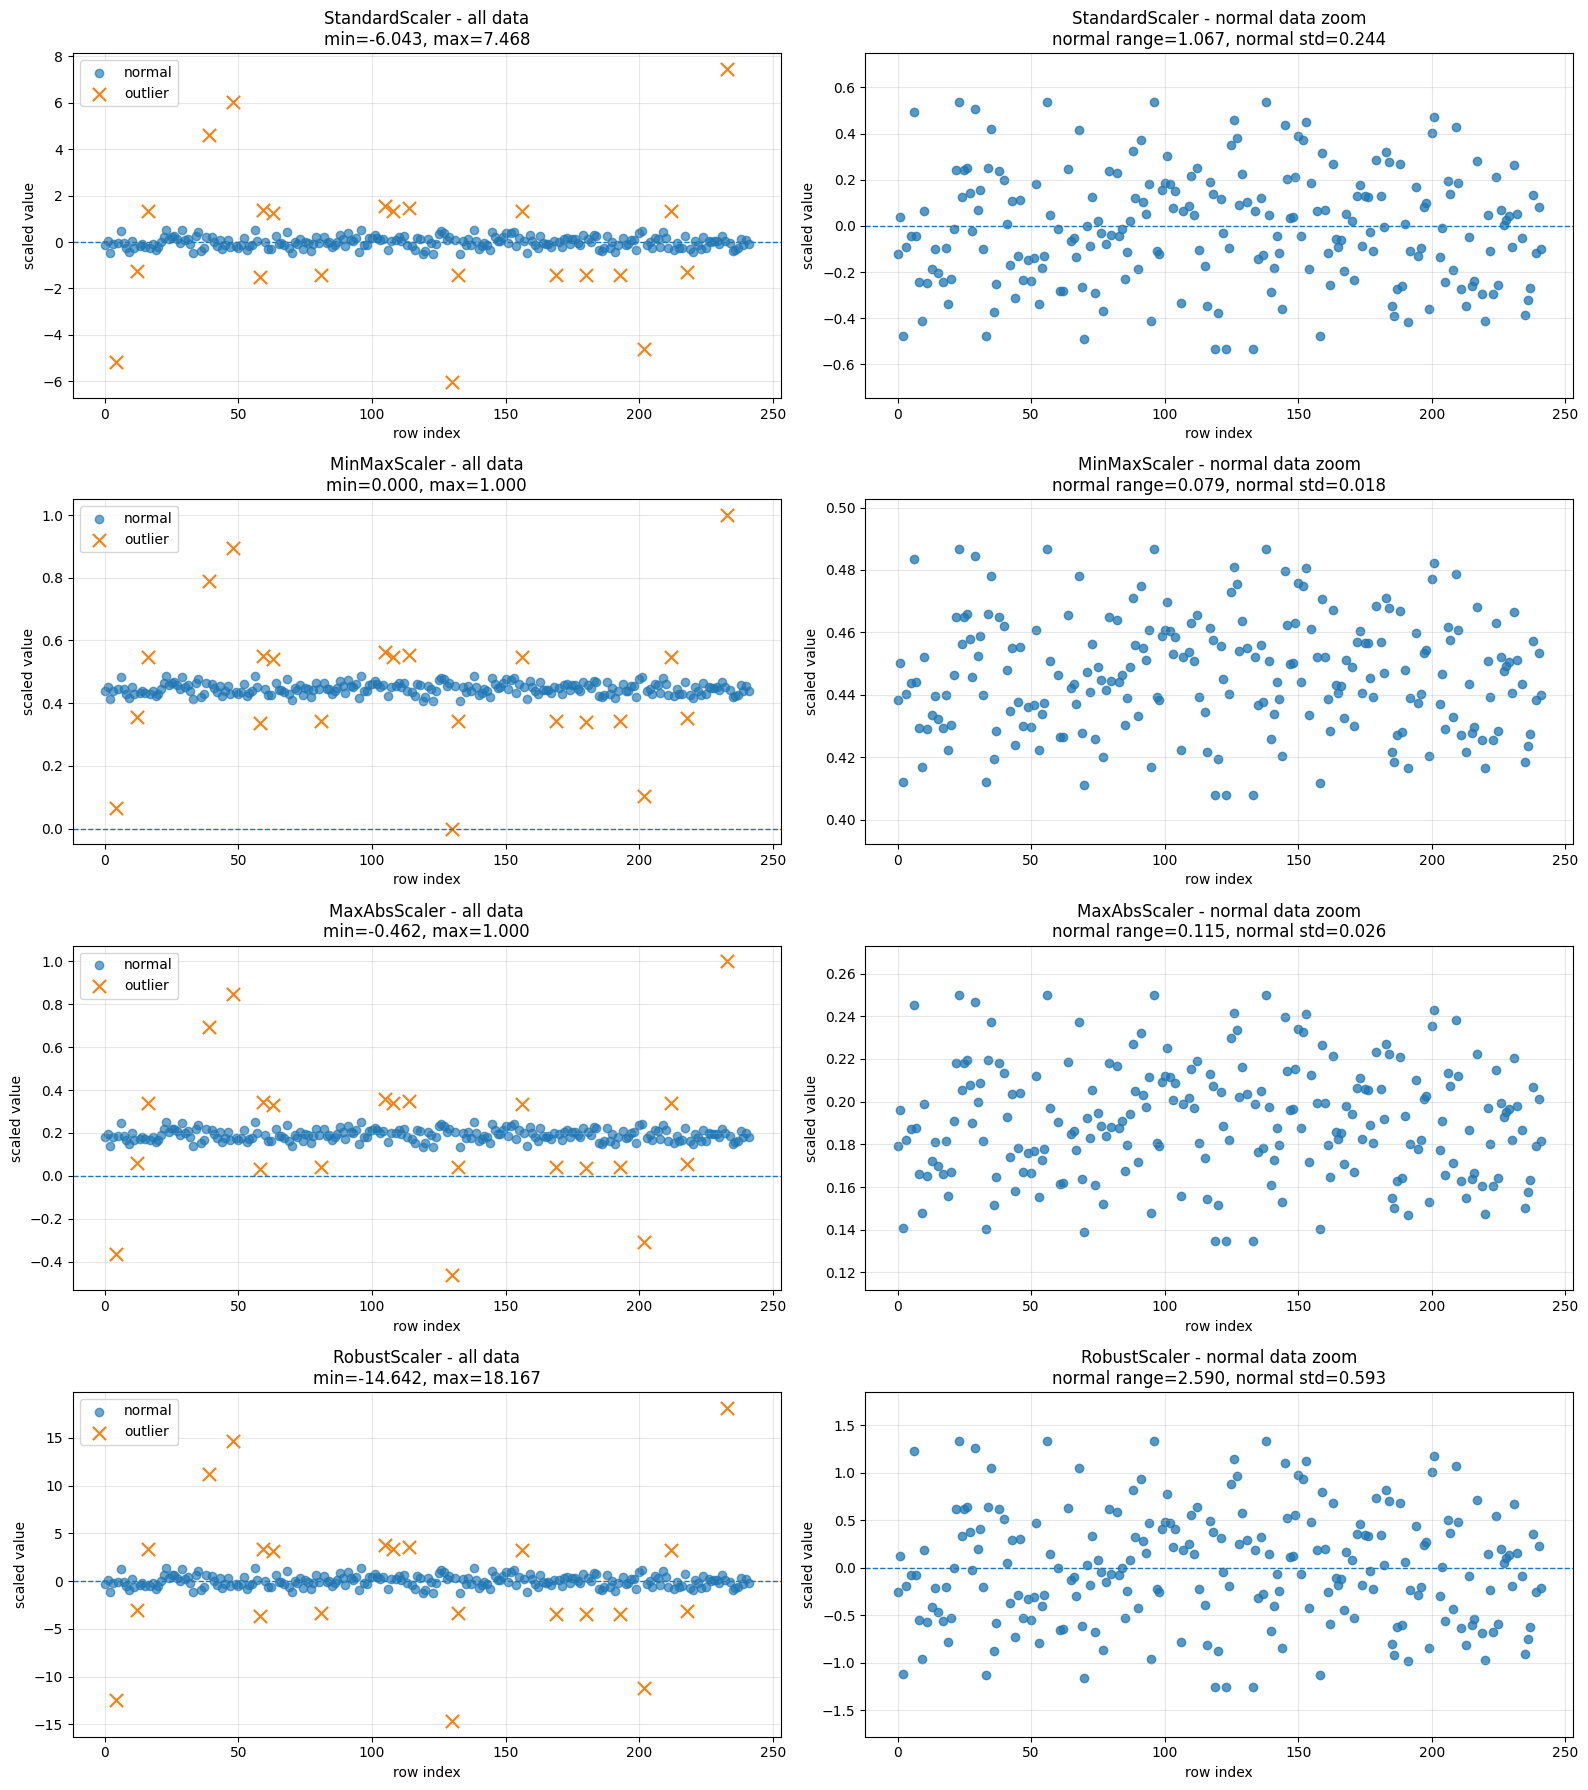

In [25]:
plot_scaler_comparison_with_outliers_vertical(scaled_df, list(scalers.keys()))

# `Pipeline` + `ColumnTransformer` 정의

**목표**: 컬럼 인덱스 `[0, 1]`(수치)에는 `StandardScaler`, `[2, 3]`(카테고리)에는 `OneHotEncoder`를 매핑하고, 그 위에 `LogisticRegression`을 얹은 두 단계 Pipeline을 만듭니다.

In [24]:
import numpy as np

rng = np.random.default_rng(42)
n = 500
X_num = rng.normal(0, 1, size=(n, 2))                     # age, bmi
X_cat = rng.choice(['M', 'F'], size=(n, 1))               # gender
country = rng.choice(['US', 'EU', 'KR'], size=(n, 1))
X_mixed = np.hstack([X_num, X_cat, country])              # (500, 4) object array
y_mixed = (X_num[:, 0] > 0).astype(int)                    # age > 0이면 1

print("X_mixed.shape =", X_mixed.shape, "y_mixed.shape =", y_mixed.shape)
print("X_mixed[:3] =")
print(X_mixed[:3])

X_mixed.shape = (500, 4) y_mixed.shape = (500,)
X_mixed[:3] =
[['0.30471707975443135' '-1.0399841062404955' 'M' 'KR']
 ['0.7504511958064572' '0.9405647163912139' 'F' 'KR']
 ['-1.9510351886538364' '-1.302179506862318' 'M' 'KR']]


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), [0, 1]),
    ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', sparse_output=False), [2, 3]),
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000)),
])
print(pipe)

In [ ]:
pipe.fit(X_mixed, y_mixed)

## 예제: `cross_val_score` 한 줄로 leakage-free 평가

**목표**: `cross_val_score(pipe, X_mixed, y_mixed, cv=5)`로 5-fold cv를 돌려 각 fold의 train에서만 `pre.fit`, test fold에는 `pre.transform`만 일어나는 leakage 방지 패턴을 자동 적용합니다.

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe, X_mixed, y_mixed, cv=5)
print("cv accuracy =", scores.round(3).tolist())
print("mean        =", round(float(scores.mean()), 3))

# 확장 전처리 도구 4종

## KBinsDiscretizer: 연속형 숫자를 구간 번호로 바꾸기

**상황**: 나이처럼 연속적인 숫자를 `0번 구간`, `1번 구간`, `2번 구간`, `3번 구간`처럼 범주형 구간으로 나누고 싶을 때 사용합니다.

- 원본: `18, 21, 25, ...`처럼 다양한 숫자
- 변환 후: `0, 0, 1, 1, ...`처럼 구간 번호
- `strategy="quantile"`: 각 구간에 샘플 수가 비슷하게 들어가도록 경계값을 정합니다.

In [ ]:
import sklearn
print(sklearn.__version__)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from IPython.display import display

In [ ]:
age = np.array([18, 19, 21, 22, 25, 28, 31, 35, 39, 44, 50, 57, 63, 72, 80]).reshape(-1, 1)

In [ ]:
kbd = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="quantile")
age_bin = kbd.fit_transform(age).astype(int).ravel()

In [ ]:
kbins_df = pd.DataFrame({
    "원본_나이": age.ravel(),
    "KBinsDiscretizer_구간번호": age_bin,
})

In [ ]:
print("구간 경계값(bin edges):", np.round(kbd.bin_edges_[0], 2))
display(kbins_df)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(kbins_df.index, kbins_df["원본_나이"], s=80)
axes[0].set_title("Before: continuous age")
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Age")

axes[1].scatter(kbins_df.index, kbins_df["KBinsDiscretizer_구간번호"], s=80)
axes[1].set_title("After: bin number")
axes[1].set_xlabel("Sample index")
axes[1].set_ylabel("Bin number")
axes[1].set_yticks(sorted(kbins_df["KBinsDiscretizer_구간번호"].unique()))

plt.tight_layout()
plt.show()


**해석**: `KBinsDiscretizer`는 숫자의 정확한 크기를 그대로 쓰는 대신, 어느 구간에 속하는지를 새 값으로 만듭니다. 선형 모델이 비선형 패턴을 잡기 어렵거나, 숫자를 등급처럼 다루고 싶을 때 유용합니다.

## `SelectKBest`: target과 관련이 큰 feature만 고르기

**상황**: feature가 너무 많을 때, target과 통계적으로 관련이 큰 상위 `k`개 feature만 남기고 싶을 때 사용합니다.

아래 예제에서는 `합격여부`가 주로 `공부시간`, `모의고사점수`에 의해 결정되도록 데이터를 만들었습니다. `SelectKBest`가 이 두 feature를 잘 고르는지 확인합니다.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif
from IPython.display import display

rng = np.random.default_rng(7)
n = 180
study_hours = rng.normal(5, 1.5, n).clip(0, 10)
sleep_hours = rng.normal(7, 1.0, n).clip(3, 10)
mock_score = rng.normal(70, 12, n).clip(0, 100)
random_noise = rng.normal(0, 1, n)
shoe_size = rng.normal(260, 10, n)  # 합격과 거의 무관한 feature

# 합격여부는 공부시간과 모의고사점수의 영향을 크게 받도록 만듭니다.
score_for_pass = 0.9 * study_hours + 0.08 * mock_score + rng.normal(0, 1.2, n)
y_pass = (score_for_pass > np.median(score_for_pass)).astype(int)

X_select = pd.DataFrame({
    "공부시간": study_hours,
    "수면시간": sleep_hours,
    "모의고사점수": mock_score,
    "랜덤노이즈": random_noise,
    "신발사이즈": shoe_size,
})

selector = SelectKBest(score_func=f_classif, k=2)
X_selected = selector.fit_transform(X_select, y_pass)
selected_features = X_select.columns[selector.get_support()].tolist()

score_df = pd.DataFrame({
    "feature": X_select.columns,
    "plot_label": ["study_hours", "sleep_hours", "mock_score", "random_noise", "shoe_size"],
    "SelectKBest_score": selector.scores_,
    "선택여부": selector.get_support(),
}).sort_values("SelectKBest_score", ascending=False)

print("변환 전 X shape:", X_select.shape)
print("변환 후 X_selected shape:", X_selected.shape)
print("선택된 feature:", selected_features)
display(score_df.round(3))

plt.figure(figsize=(10, 4))
plt.bar(score_df["plot_label"], score_df["SelectKBest_score"])
plt.title("SelectKBest feature score comparison")
plt.xlabel("feature")
plt.ylabel("score")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


**해석**: 막대가 높을수록 target인 `합격여부`와 관련이 크다고 판단된 feature입니다. `SelectKBest(k=2)`를 사용했기 때문에 점수가 가장 높은 feature 2개만 남습니다.

## `FunctionTransformer`: 내가 원하는 함수로 변환기 만들기

**상황**: `log1p`, 제곱근, 사용자 정의 함수처럼 scikit-learn에 완성된 transformer로 없는 간단한 변환을 Pipeline 안에 넣고 싶을 때 사용합니다.

아래 예제에서는 `월방문수`처럼 한쪽으로 치우친 데이터에 `np.log1p(x)`를 적용해 큰 값을 눌러 줍니다.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import FunctionTransformer
from IPython.display import display

rng = np.random.default_rng(11)
monthly_visits = rng.exponential(scale=25, size=300).astype(int)
monthly_visits[:5] = [150, 180, 220, 260, 320]  # 일부 큰 값 추가

X_func = pd.DataFrame({"월방문수": monthly_visits})

log_transformer = FunctionTransformer(np.log1p, feature_names_out="one-to-one")
X_log = log_transformer.fit_transform(X_func)

func_df = X_func.copy()
func_df["log1p_월방문수"] = X_log["월방문수"]

display(func_df.head(10).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(func_df["월방문수"], bins=30)
axes[0].set_title("Before: monthly visits")
axes[0].set_xlabel("Monthly visits")
axes[0].set_ylabel("Count")

axes[1].hist(func_df["log1p_월방문수"], bins=30)
axes[1].set_title("After: log1p(monthly visits)")
axes[1].set_xlabel("log1p value")

plt.tight_layout()
plt.show()


**해석**: `log1p` 변환은 0도 안전하게 처리하면서 큰 값을 작게 눌러 줍니다. 방문수, 매출, 조회수처럼 소수의 큰 값 때문에 분포가 심하게 오른쪽으로 치우친 데이터에서 자주 사용합니다.

# `TargetEncoder`: 카테고리를 target 평균 기반 숫자로 바꾸기

**공식 문서 기반 핵심 아이디어**

`TargetEncoder`는 카테고리 값을 target의 평균값에 가까운 숫자로 바꿉니다. 예를 들어 `상품카테고리 = 라면`인 행들의 평균 구매율이 높다면, `라면`은 높은 숫자로 인코딩됩니다.

중요한 점은 `TargetEncoder`가 `y`를 사용한다는 것입니다. 그래서 모델 평가에서는 **반드시 Pipeline 안에 넣고 교차검증**해야 target leakage를 줄일 수 있습니다. scikit-learn 공식 문서에서도 `fit_transform`은 training data를 인코딩할 때 leakage와 과적합을 줄이기 위해 내부 cross-fitting을 사용한다고 설명합니다.

참고 문서:

- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.TargetEncoder.html
- https://scikit-learn.org/stable/auto_examples/preprocessing/plot_target_encoder_cross_val.html

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import TargetEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from IPython.display import display

rng = np.random.default_rng(123)
n = 600

# 초보자용 샘플 데이터: 상품카테고리에 따라 구매 확률이 다르다고 가정합니다.
products = np.array(["Ramen", "Milk", "Premium snack", "Vitamins", "Household"])
purchase_rate = {
    "Ramen": 0.70,
    "Milk": 0.55,
    "Premium snack": 0.35,
    "Vitamins": 0.25,
    "Household": 0.45,
}

product_col = rng.choice(products, size=n, p=[0.25, 0.25, 0.20, 0.15, 0.15])
y_buy = np.array([rng.binomial(1, purchase_rate[p]) for p in product_col])

X_te = pd.DataFrame({"상품카테고리": product_col})
te_df = X_te.copy()
te_df["구매여부"] = y_buy

display(te_df.head(10))

# 1) 원리 확인: 카테고리별 실제 구매율을 직접 계산합니다.
category_rate = (
    te_df.groupby("상품카테고리")["구매여부"]
    .mean()
    .sort_values(ascending=False)
    .reset_index(name="실제_카테고리별_구매율")
)
display(category_rate.round(3))

plt.figure(figsize=(8, 4))
plt.bar(category_rate["상품카테고리"], category_rate["실제_카테고리별_구매율"])
plt.title("Before: purchase rate by category")
plt.xlabel("Product category")
plt.ylabel("Mean purchase rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 2) TargetEncoder가 각 카테고리를 어떤 숫자로 저장하는지 확인합니다.
#    이 fit + transform 방식은 원리 설명용입니다. 모델 평가는 아래 Pipeline 방식으로 합니다.
te_explain = TargetEncoder(smooth="auto", random_state=0)
te_explain.fit(X_te, y_buy)

encoding_table = pd.DataFrame({
    "상품카테고리": te_explain.categories_[0],
    "TargetEncoder_저장값": te_explain.encodings_[0],
}).sort_values("TargetEncoder_저장값", ascending=False)

display(encoding_table.round(3))

plt.figure(figsize=(8, 4))
plt.bar(encoding_table["상품카테고리"], encoding_table["TargetEncoder_저장값"])
plt.title("After TargetEncoder: category as number")
plt.xlabel("Product category")
plt.ylabel("Encoded value")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 3) 실제 모델 평가에서는 Pipeline 안에 TargetEncoder를 넣습니다.
te_pipe = Pipeline([
    ("target_encoder", TargetEncoder(smooth="auto", cv=5, random_state=0)),
    ("model", LogisticRegression(max_iter=1000)),
])

onehot_pipe = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ("model", LogisticRegression(max_iter=1000)),
])

te_scores = cross_val_score(te_pipe, X_te, y_buy, cv=5, scoring="accuracy")
oh_scores = cross_val_score(onehot_pipe, X_te, y_buy, cv=5, scoring="accuracy")

print(f"TargetEncoder Pipeline CV accuracy 평균: {te_scores.mean():.3f}")
print(f"OneHotEncoder  Pipeline CV accuracy 평균: {oh_scores.mean():.3f}")

# 4) 새로운 데이터가 들어왔을 때 transform 결과 보기
new_products = pd.DataFrame({"상품카테고리": ["Ramen", "Vitamins", "New product"]})
print("\n새로운 데이터 transform 결과")
display(pd.DataFrame({
    "상품카테고리": new_products["상품카테고리"],
    "TargetEncoded": te_explain.transform(new_products).ravel(),
}).round(3))


**해석**:

- `TargetEncoder`는 `라면`, `우유` 같은 문자열 카테고리를 구매율과 관련된 숫자로 바꿉니다.
- `OneHotEncoder`는 카테고리 수만큼 컬럼을 늘리지만, `TargetEncoder`는 보통 카테고리 feature 1개를 숫자 feature 1개로 바꿉니다.
- 단, `TargetEncoder`는 target `y`를 사용하므로 train/test 분리 전에 전체 데이터에 먼저 적용하면 leakage가 생길 수 있습니다. 그래서 실전에서는 마지막 예제처럼 `Pipeline` 안에 넣고 `cross_val_score`, `GridSearchCV`, `train_test_split` 이후 학습 절차와 함께 사용하세요.